In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, random_split, TensorDataset
import torch.nn.functional as torch_F # avoid import problems becasue F is used as a variable

import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

import sys
sys.path.append('../src')

from preprocessing import *
from models import  *
from utils import *

from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
dfs = get_dfs(os.path.dirname(os.getcwd()))
static_df = create_static_df(dfs)
medication_df = create_medication_df(dfs)
vitals_ca, vitals_lab = create_vitals_df(dfs)
biopsy_df = dfs['biopsy']

ts_data = create_ts_data(vitals_ca, vitals_lab, medication_df, merge_lab=True, merge_med=True, static_df=static_df)

#notes = create_notes_df(dfs, filename='../data/embeddings/emb_gte.npy')
notes = create_notes_df(dfs, filename='../data/embeddings/emb_med_gte_simcse_en_ger.npy')
#notes = create_notes_df(dfs, filename=None)

full_dataset = NephroCAGEDataset(static_df=static_df, ts_data=ts_data, notes_df=notes, biopsy_df=biopsy_df)
datapoints_limit = len(full_dataset)
datapoints_limit = 320 
dataset = Subset(full_dataset, indices=list(range(datapoints_limit)))
ts_scaler = full_dataset.ts_scaler
static_scaler = full_dataset.scaler

Unique patients in medication: 3335
Removing patients that are not in static_df
Unique patients in clinical assessments: 3296
Average entries per patient 78.9
Unique patients in clinical assessments: 3465
Removing patients that are not in static_df
Unique patients in clinical assessments: 3423
Average entries per patient 61.16155419222904
Unique patients in lab df: 3460
Removing patients that are not in static_df
Unique patients in lab df: 3410
Average entries per patient 472.2140762463343
Reading notes from exams.csv
Found 206509 texts
Loading 215137 texts from clinical assessments
Concatenated texts and deleted NaNs, final count: 367140
Average texts per patient: 106.9
3382 patients remain after removing no-notes patients.



In [5]:
# Split dataset into training and test sets (80% train, 20% test)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

batch_size = 16
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
full_dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)

#vanilla_lstm = VanillaTimeSeriesEncoder()
att_encoder = TimeAwareAttentionEncoder(use_temporal_attention=True)
model = MultiModalVAE(att_encoder, categorical_cardinalities=full_dataset.categorical_cardinalities, use_static=True, use_notes=False).to(device)
predict_steps_ahead = 1
lambda_corr = 0.1
lambda_modality_mi = 0
lambda_feature_loss = 0.1

/home/sr100@hsg.privat/x-med/.venv/lib/python3.10/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [6]:
criterion = nn.MSELoss(reduction='none')
optimizer = optim.Adam(model.parameters(), lr=0.0003)

feature_decoders = FeatureDecoders(CONFIG['lstm_hidden_size'], CONFIG).to(device)
feature_decoder_optimizer = optim.Adam(feature_decoders.parameters(), lr=0.0003)

# VAE specific hyperparameters
kl_weight = 0.001  # Start with a small weight for KL term
kl_annealing = True  # Whether to use KL annealing
kl_start = 0.0  # Starting weight for KL term
kl_end = 0.01  # Final weight for KL term

num_epochs = 3

with tqdm(total=num_epochs * len(full_dataloader), desc="Training", leave=True) as pbar:
    for epoch in range(num_epochs):
        total_loss = 0.0
        total_kl_loss = 0.0
        total_recon_loss = 0.0
        total_valid_points = 0.0
        model.train()
        
        # KL annealing - gradually increase the weight of the KL term
        if kl_annealing:
            kl_weight = kl_start + (kl_end - kl_start) * min(1.0, epoch / (num_epochs * 0.75))
        
        for batch_idx, batch in enumerate(full_dataloader):
            cat_features = batch['static_categorical_features'].to(device)
            num_features_input = batch['static_numerical_features'].to(device)
            
            # full_seq shape: (B, T, F)
            full_seq = batch['ts_features'].to(device)
            timesteps = batch['timesteps'].to(device)     # (B, T)
            value_mask_full = batch['value_mask'].to(device)  # (B, T, F)
            mask = batch['mask'].to(device)               # (B, T) => True=valid data, False=pad
            B, T, F = full_seq.shape

            notes_embeddings = batch['notes_embeddings'].to(device)
            notes_timesteps = batch['notes_timesteps'].to(device)
            notes_mask = batch['notes_mask'].to(device)

            # We need at least 2 timesteps to do 1-step-ahead training
            if T <= predict_steps_ahead:
                continue
            
            # x => all steps except the last (for input)
            # shape => (B, T-1, F)
            input_seq = full_seq[:, :-predict_steps_ahead, :]
            
            # timesteps => we also omit the last one, shape => (B, T-1)
            input_timesteps = timesteps[:, :-predict_steps_ahead]
            
            # Elapsed times => difference between consecutive steps
            # then take only the first (T - predict_steps_ahead) deltas
            delta_times = timesteps[:, 1:] - timesteps[:, :-1]   # (B, T-1)
            elapsed_times = delta_times[:, : (T - predict_steps_ahead)]
            
            input_mask = mask[:, :-predict_steps_ahead]  # (B, T-1)
            
            # shape => (B, T-1, F)
            optimizer.zero_grad()
            feature_decoder_optimizer.zero_grad()
            
            # VAE forward pass now returns additional mu and logvar
            outputs, hidden_states, attention_weights, static_embedding, mu, logvar = model(
                x=input_seq,
                elapsed_times=elapsed_times,
                timesteps=input_timesteps,
                notes_embeddings=notes_embeddings,
                notes_timesteps=notes_timesteps,
                static_features=(cat_features, num_features_input),
                mask=input_mask,
                notes_mask=notes_mask
            )
            
            # target => all steps from index 1..T-predict_steps_ahead
            # shape => (B, T-predict_steps_ahead, F)
            target_seq = full_seq[:, predict_steps_ahead:, :]
            
            # valid_mask => the same region
            valid_mask = value_mask_full[:, predict_steps_ahead:, :]
            
            # Reconstruction loss (same as before)
            raw_loss = criterion(outputs, target_seq)  # (B, T-1, F)
            masked_loss = raw_loss * valid_mask.float()   # elementwise
            valid_points = valid_mask.float().sum()    # total count of valid features
            
            recon_loss = masked_loss.sum() / valid_points if valid_points > 0 else torch.tensor(0.0, device=device)

            # KL divergence loss - calculated from mu and logvar
            # Only apply KL to non-padding positions
            time_mask = input_mask.unsqueeze(-1).float()  # (B, T-1, 1)
            kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=-1)  # (B, T-1)
            masked_kl_div = kl_div * input_mask.float()  # Apply time mask
            valid_timesteps = input_mask.float().sum()
            kl_loss = masked_kl_div.sum() / valid_timesteps if valid_timesteps > 0 else torch.tensor(0.0, device=device)

            # Keep your existing additional losses
            decorr_loss = correlation_loss(hidden_states[:, -1, :])
            
            mi_loss = modality_mi_loss(
                hidden_states[:, -1, :],  # Use final hidden state
                static_embedding,         # Static embeddings from model output
                notes_embeddings[:, -1, :]   # Use last notes embedding if sequential
            )

            feature_preds, masks = feature_decoders(hidden_states[:, -1, :])

            feat_pred_loss = feature_prediction_loss(
                feature_preds, 
                masks,
                cat_features,  # Your categorical features
                num_features_input,  # Your numerical features
                full_seq[:, -1, :]  # Last timestep of ts features
            )

            # Combine all losses, now including the KL term
            total_loss = recon_loss + kl_weight * kl_loss + lambda_corr * decorr_loss + lambda_modality_mi * mi_loss

            total_loss.backward()
            optimizer.step()
            feature_decoder_optimizer.step()

            # For logging
            batch_size = input_seq.size(0)
            total_recon_loss += recon_loss.item() * valid_points
            total_kl_loss += kl_loss.item() * valid_timesteps
            total_loss += total_loss.item() * valid_points
            total_valid_points += valid_points
            
            pbar.update(1)
            if total_valid_points > 0:
                avg_loss = (total_loss / total_valid_points).item()
                avg_recon_loss = (total_recon_loss / total_valid_points).item()
                avg_kl_loss = (total_kl_loss / valid_timesteps).item() if valid_timesteps > 0 else 0
                
                pbar.set_postfix({
                    'Epoch': f"{epoch+1}/{num_epochs}",
                    'Avg Loss': f"{avg_loss:.4f}",
                    'Recon Loss': f"{avg_recon_loss:.4f}",
                    'KL Loss': f"{avg_kl_loss:.6f} (w={kl_weight:.6f})",
                    'Corr Loss': f"{decorr_loss.item():.4f}",
                    'MI Loss': f"{mi_loss.item():.4f}",
                })

print("Training completed.")
torch.save(model.state_dict(), "../models/vae_nonotes_corrfelo.pt")

Training: 100%|██████████| 60/60 [00:52<00:00,  1.14it/s, Epoch=3/3, Avg Loss=0.0555, Recon Loss=0.9266, KL Loss=436.772430 (w=0.008889), Corr Loss=0.0934, MI Loss=0.6823] 

Training completed.


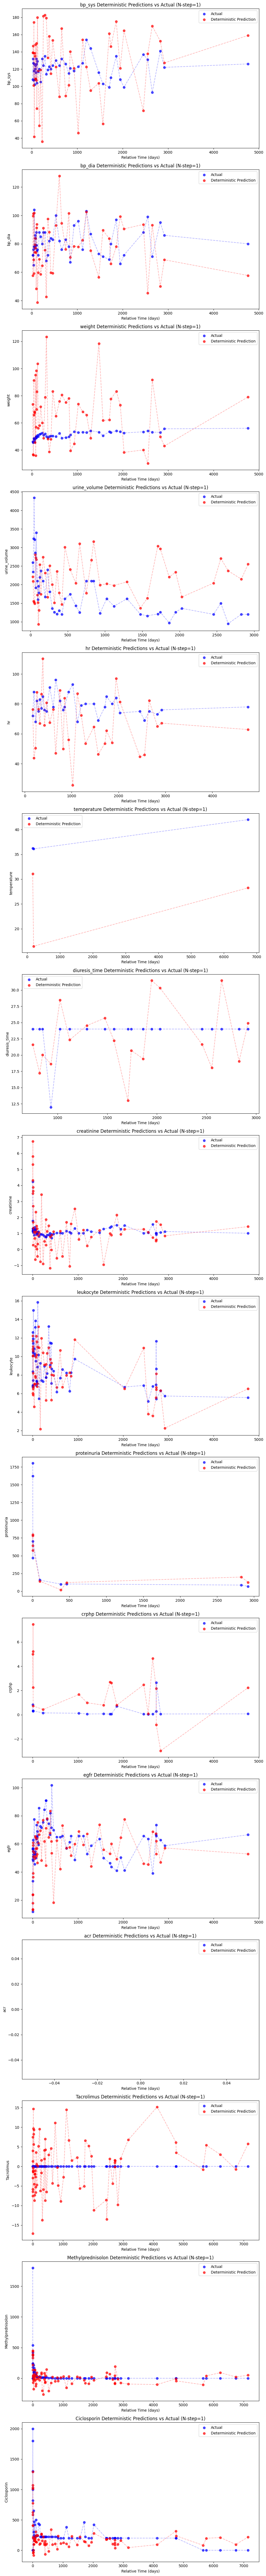

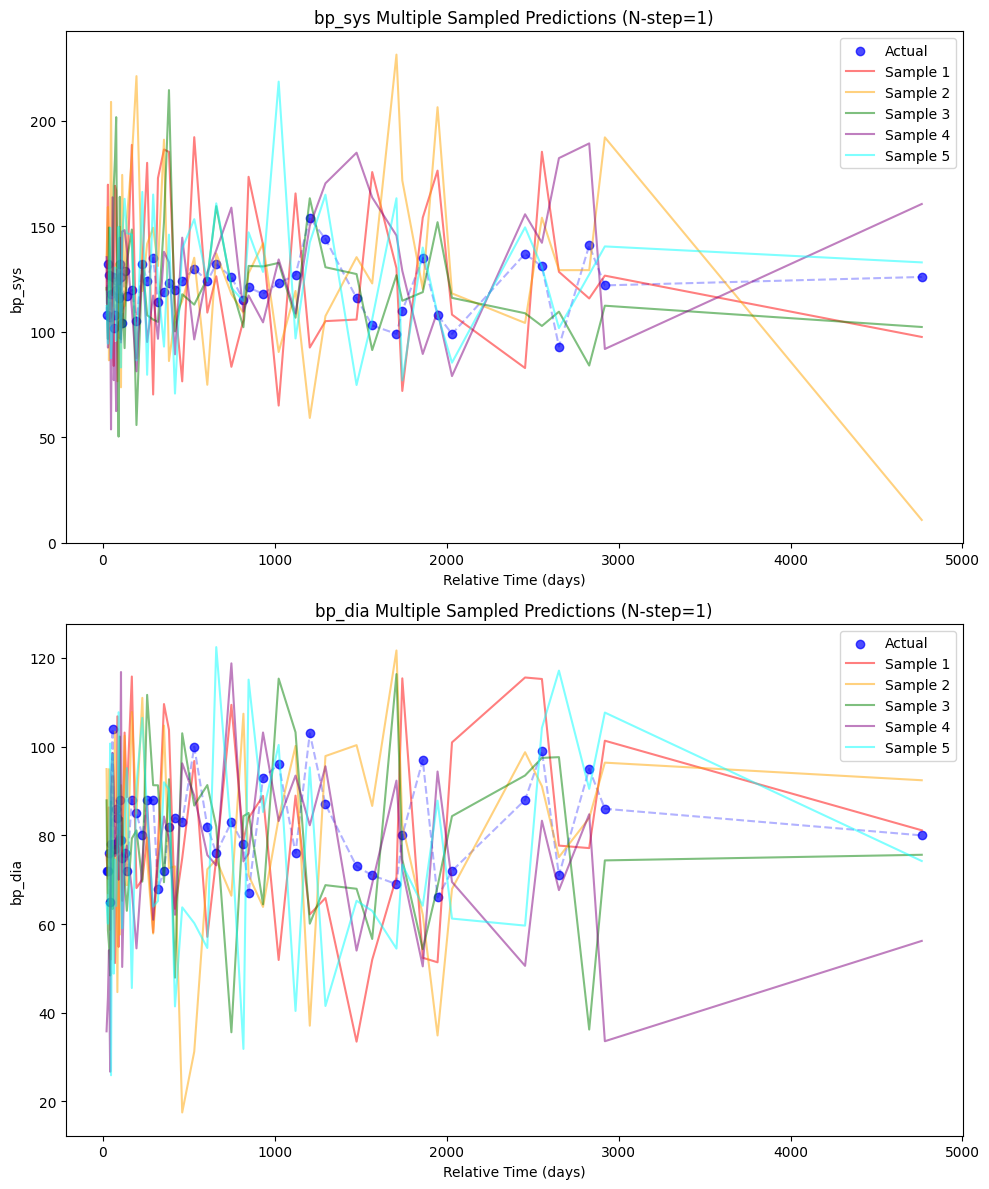

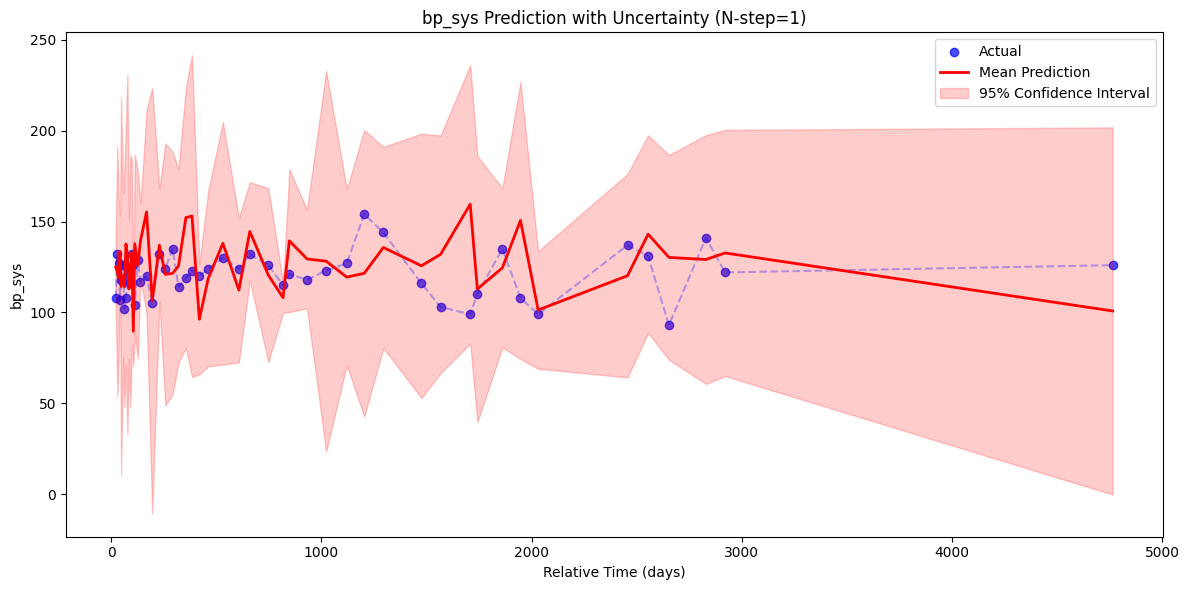

In [7]:
model.eval()
with torch.no_grad():
    for batch in test_dataloader:
        cat_features = batch['static_categorical_features'].to(device)
        num_features = batch['static_numerical_features'].to(device)

        full_seq = batch['ts_features'].to(device)       # (B, T, F)
        timesteps = batch['timesteps'].to(device)        # (B, T)
        value_mask_full = batch['value_mask'].to(device) # (B, T, F)

        notes_embeddings = batch['notes_embeddings'].to(device)
        notes_timesteps = batch['notes_timesteps'].to(device)
        notes_mask = batch['notes_mask'].to(device)

        B, T, F = full_seq.shape

        # Skip if sequence is too short for the desired horizon
        if T <= predict_steps_ahead:
            continue

        # Input => (B, T - n, F)
        input_seq = full_seq[:, :-predict_steps_ahead, :]
        # Target => (B, T - n, F)
        target_seq = full_seq[:, predict_steps_ahead:, :]

        # Elapsed times => (B, T-1), keep only first (T - n)
        delta_times = timesteps[:, 1:] - timesteps[:, :-1]  # shape (B, T-1)
        elapsed_times = delta_times[:, : (T - predict_steps_ahead)]

        # Value mask => for the same target portion
        value_mask = value_mask_full[:, predict_steps_ahead:, :]

        # VAE forward pass now returns mu and logvar
        outputs, hidden_states, attention_weights, static_embedding, mu, logvar = model(
            x=input_seq,
            elapsed_times=elapsed_times,
            timesteps=timesteps[:, :-predict_steps_ahead],
            notes_embeddings=notes_embeddings,
            notes_timesteps=notes_timesteps,
            static_features=(cat_features, num_features),
            mask=batch['mask'][:, :-predict_steps_ahead].to(device),  # (B, T - n)
            notes_mask=notes_mask
        )
        
        # Generate multiple samples from the latent distribution for one patient
        patient_idx = 2  # Choose a sample patient
        num_samples = 5  # Number of different future scenarios to generate
        
        # Extract patient-specific values
        patient_mu = mu[patient_idx:patient_idx+1]       # (1, T-n, hidden_size)
        patient_logvar = logvar[patient_idx:patient_idx+1]  # (1, T-n, hidden_size)
        
        # Generate different samples
        sampled_outputs = []
        for i in range(num_samples):
            # Sample z using reparameterization trick
            std = torch.exp(0.5 * patient_logvar)
            eps = torch.randn_like(std)
            z = patient_mu + eps * std
            
            # Decode to get prediction (reusing the decoder part of your model)
            sample_output = model.ff(z)  # (1, T-n, F)
            sampled_outputs.append(sample_output)
        
        # Bring deterministic output to CPU for plotting / inverse transform
        outputs_np = outputs.cpu().numpy()
        target_np = target_seq.cpu().numpy()
        value_mask_np = value_mask.cpu().numpy()
        timesteps_np = timesteps.cpu().numpy()

        B_, TmN, F_ = outputs_np.shape  # TmN = T - n

        # Reshape for scaler
        outputs_2d = outputs_np.reshape(-1, F_)
        target_2d = target_np.reshape(-1, F_)

        # Apply inverse scaling
        outputs_orig = ts_scaler.inverse_transform(outputs_2d).reshape(B_, TmN, F_)
        target_orig = ts_scaler.inverse_transform(target_2d).reshape(B_, TmN, F_)
        
        # Process the sampled outputs for the selected patient
        sampled_outputs_np = []
        for sample in sampled_outputs:
            # Extract the single patient's output and reshape for inverse transform
            sample_np = sample.cpu().numpy()
            sample_2d = sample_np.reshape(-1, F_)
            # Apply inverse scaling
            sample_orig = ts_scaler.inverse_transform(sample_2d).reshape(1, TmN, F_)
            sampled_outputs_np.append(sample_orig[0])  # Keep just the patient data, not the batch dimension

        patient_idx = 2
        pred_values = outputs_orig[patient_idx]    # shape (T - n, F)
        true_values = target_orig[patient_idx]     # shape (T - n, F)
        mask_vals = value_mask_np[patient_idx]     # shape (T - n, F)

        # Time steps for those predicted points: (T - n) steps from index n onward
        patient_timesteps = timesteps_np[patient_idx, predict_steps_ahead:]  # shape (T - n,)

        feature_idx = list(range(len(CONFIG['ts_features'])))
        num_features_to_plot = len(feature_idx)
        fig, axs = plt.subplots(num_features_to_plot, 1, figsize=(10, 6 * num_features_to_plot))

        # Handle single axis vs multiple
        if num_features_to_plot == 1:
            axs = [axs]

        for i, f_idx in enumerate(feature_idx):
            valid_indices = (mask_vals[:, f_idx] == 1)

            axs[i].scatter(patient_timesteps[valid_indices],
                          true_values[valid_indices, f_idx],
                          color='blue', label='Actual', alpha=0.7)
            axs[i].plot(patient_timesteps[valid_indices],
                       true_values[valid_indices, f_idx],
                       color='blue', alpha=0.3, linestyle='--')

            axs[i].scatter(patient_timesteps[valid_indices],
                          pred_values[valid_indices, f_idx],
                          color='red', label='Deterministic Prediction', alpha=0.7)
            axs[i].plot(patient_timesteps[valid_indices],
                       pred_values[valid_indices, f_idx],
                       color='red', alpha=0.3, linestyle='--')

            feature_name = CONFIG['ts_features'][f_idx]
            axs[i].set_title(f"{feature_name} Deterministic Predictions vs Actual (N-step={predict_steps_ahead})")
            axs[i].set_xlabel("Relative Time (days)")
            axs[i].set_ylabel(feature_name)
            axs[i].legend()

        plt.tight_layout()
        plt.savefig("vae_deterministic_prediction.png")
        plt.show()

        features_to_show = [0, 1] if len(feature_idx) > 1 else [0]
        num_stochastic_plots = len(features_to_show)
        fig, axs = plt.subplots(num_stochastic_plots, 1, figsize=(10, 6 * num_stochastic_plots))
        
        # Handle single axis
        if num_stochastic_plots == 1:
            axs = [axs]
            
        sample_colors = ['red', 'orange', 'green', 'purple', 'cyan']
        
        for i, f_idx in enumerate(features_to_show):
            valid_indices = (mask_vals[:, f_idx] == 1)
            
            # Plot ground truth
            axs[i].scatter(patient_timesteps[valid_indices],
                          true_values[valid_indices, f_idx],
                          color='blue', label='Actual', alpha=0.7)
            axs[i].plot(patient_timesteps[valid_indices],
                       true_values[valid_indices, f_idx],
                       color='blue', alpha=0.3, linestyle='--')
            
            # Plot each sampled prediction
            for s_idx, sample in enumerate(sampled_outputs_np):
                if s_idx < len(sample_colors):  # Ensure we have enough colors
                    color = sample_colors[s_idx]
                    axs[i].plot(patient_timesteps[valid_indices],
                               sample[valid_indices, f_idx],
                               color=color, alpha=0.5, linestyle='-',
                               label=f'Sample {s_idx+1}')
            
            feature_name = CONFIG['ts_features'][f_idx]
            axs[i].set_title(f"{feature_name} Multiple Sampled Predictions (N-step={predict_steps_ahead})")
            axs[i].set_xlabel("Relative Time (days)")
            axs[i].set_ylabel(feature_name)
            axs[i].legend()
        
        plt.tight_layout()
        plt.savefig("vae_stochastic_predictions.png")
        plt.show()
        
        if len(feature_idx) > 0:
            feature_to_show = 0  # Index of feature to visualize
            fig, ax = plt.subplots(figsize=(12, 6))
            
            valid_indices = (mask_vals[:, feature_to_show] == 1)
            
            # Plot ground truth
            ax.scatter(patient_timesteps[valid_indices],
                      true_values[valid_indices, feature_to_show],
                      color='blue', label='Actual', alpha=0.7)
            ax.plot(patient_timesteps[valid_indices],
                   true_values[valid_indices, feature_to_show],
                   color='blue', alpha=0.3, linestyle='--')
            
            # Calculate mean and std from samples
            samples_array = np.array([sample[valid_indices, feature_to_show] for sample in sampled_outputs_np])
            mean_prediction = np.mean(samples_array, axis=0)
            std_prediction = np.std(samples_array, axis=0)
            
            # Plot mean prediction
            ax.plot(patient_timesteps[valid_indices], mean_prediction,
                   color='red', label='Mean Prediction', linewidth=2)
            
            # Plot confidence intervals (±2 std for ~95% confidence)
            ax.fill_between(patient_timesteps[valid_indices],
                           mean_prediction - 2 * std_prediction,
                           mean_prediction + 2 * std_prediction,
                           color='red', alpha=0.2, label='95% Confidence Interval')
            
            feature_name = CONFIG['ts_features'][feature_to_show]
            ax.set_title(f"{feature_name} Prediction with Uncertainty (N-step={predict_steps_ahead})")
            ax.set_xlabel("Relative Time (days)")
            ax.set_ylabel(feature_name)
            ax.legend()
            
            plt.tight_layout()
            plt.savefig("vae_uncertainty_visualization.png")
            plt.show()

        # Just visualize for the first batch and stop
        break